In [8]:
%pip install -U seaborn xlrd watermark


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import sys
import xlrd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.executable


'c:\\Users\\User\\OneDrive\\Documentos\\Python\\Dev_Python\\Abud Python Learning\\DSA\\venv\\Scripts\\python.exe'

In [10]:
%reload_ext watermark
%watermark -a "Data Science Academy"

df_dsa = pd.read_excel(
    r'C:\Users\User\OneDrive\Documentos\Python\Dev_Python\Abud Python Learning\DSA\Módulo_1-Automação-Excel-e-Engenharia-de-Dados\3_Manipulacao-e-Engenharia-de-Dados-com-Pandas-Parte-3\dataset.xls'
)


Author: Data Science Academy



## Pipeline 1 - Estatísticas de Vendas com Pivot Table

Objetivo: Criar uma tabela com a média e desvio padrão de vendas e lucro por subcategoria. A tabela deve conter para cada registro a diferença entre a média e o desvio padrão.

Média é um valor que tenta resumir um conjunto de dados representando o "centro" desses dados. É calculada somando todos os valores do conjunto e dividindo o total pelo número de valores. A média dá uma boa ideia do que é típico ou comum para aquele conjunto de dados.

Desvio padrão é uma medida que indica a quantidade de variação ou dispersão dos dados em relação à média. Um desvio padrão baixo significa que os dados estão agrupados muito próximos da média, indicando pouca variação. Um desvio padrão alto indica que os dados estão mais espalhados, mostrando uma maior variação em relação à média.

In [11]:
# Criando a Pivot Table para calcular a média de Sales e Profit por Sub-Category
df_dsa_media_info = pd.pivot_table(df_dsa, 
                                   index = 'Sub-Category',  # ← CORRIGIDO: hífen
                                   values = ['Sales', 'Profit'], 
                                   aggfunc = 'mean').reset_index()

# Renomeando as colunas para facilitar o acesso futuro
df_dsa_media_info.columns = ['Sub_Category', 'Mean_Profit', 'Mean_Sales']

# Visualizando as primeiras linhas do resultado
df_dsa_media_info.head()

,Sub_Category,Mean_Profit,Mean_Sales
0,Accessories,54.111788,215.974604
1,Appliances,38.922758,230.755710
2,Art,8.200737,34.068834
3,Binders,19.843574,133.560560
4,Bookcases,-15.230509,503.859633


In [12]:
# Criando a Pivot Table para calcular o Desvio Padrão (std) de Sales e Profit
df_dsa_desvio_info = pd.pivot_table(df_dsa, 
                                    index = 'Sub-Category',  # ← CORRIGIDO: hífen
                                    values = ['Sales', 'Profit'], 
                                    aggfunc = 'std').reset_index()

# Ajustando os nomes das colunas para snake_case
df_dsa_desvio_info.columns = ['Sub_Category', 'STD_Profit', 'STD_Sales']

# Visualizando as primeiras linhas do resultado
df_dsa_desvio_info.head()

,Sub_Category,STD_Profit,STD_Sales
0,Accessories,106.155455,334.965015
1,Appliances,148.319146,388.949643
2,Art,13.384264,60.122465
3,Binders,306.196773,563.251188
4,Bookcases,182.034224,638.748523


In [13]:
# Unindo os DataFrames de Média e Desvio Padrão
df_pipe_1 = pd.merge(df_dsa_media_info, 
                     df_dsa_desvio_info, 
                     on = 'Sub_Category', 
                     how = 'left')

# Visualizando o resultado
df_pipe_1.head()

,Sub_Category,Mean_Profit,Mean_Sales,STD_Profit,STD_Sales
0,Accessories,54.111788,215.974604,106.155455,334.965015
1,Appliances,38.922758,230.755710,148.319146,388.949643
2,Art,8.200737,34.068834,13.384264,60.122465
3,Binders,19.843574,133.560560,306.196773,563.251188
4,Bookcases,-15.230509,503.859633,182.034224,638.748523


In [14]:
# Calcula a diferença da média de lucro em relação ao desvio
df_pipe_1['diffMean'] = df_pipe_1['Mean_Profit'] - df_pipe_1['STD_Profit']

# Calcula a diferença da média de vendas em relação ao desvio
df_pipe_1['diffSTD'] = df_pipe_1['Mean_Sales'] - df_pipe_1['STD_Sales']

# Ordena a tabela
df_pipe_1.sort_values(by = ['diffMean'], ascending = False)

,Sub_Category,Mean_Profit,Mean_Sales,STD_Profit,STD_Sales,diffMean,diffSTD
8,Fasteners,4.375660,13.936774,5.055053,12.416593,-0.679393,1.520181
2,Art,8.200737,34.068834,13.384264,60.122465,-5.183527,-26.053631
7,Envelopes,27.418019,64.867724,35.354983,84.351633,-7.936964,-19.483908
12,Paper,24.856620,57.284092,35.225214,78.167639,-10.368594,-20.883547
10,Labels,15.236962,34.303055,34.084127,74.119287,-18.847165,-39.816232
9,Furnishings,13.645918,95.825668,52.753228,147.893640,-39.107310,-52.067972
0,Accessories,54.111788,215.974604,106.155455,334.965015,-52.043667,-118.990411
14,Storage,25.152277,264.590553,81.923600,355.222507,-56.771323,-90.631953
13,Phones,50.073938,371.211534,113.251277,491.457343,-63.177339,-120.245808
5,Chairs,43.095894,532.332420,127.099922,550.148243,-84.004028,-17.815823


In [15]:
type(df_pipe_1)

pandas.core.frame.DataFrame

## Pipeline 2 - Resumo de Vendas com Pivot Table
Objetivo: Identificar as subcategorias onde estão os 20 principais clientes que têm vendas maiores do que as outras subcategorias na mesma região.

In [16]:
# Colunas
df_dsa.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [17]:
# Tabela pivot para extrair os 20 clientes com maior volume de vendas
df_cliente = pd.pivot_table(df_dsa,
                            index = ['Customer ID'],
                            values = ['Sales'], 
                            aggfunc = 'sum').reset_index().sort_values(by = 'Sales',
                                                                       ascending = False).head(20)['Customer ID'].values

In [18]:
df_cliente


array(['SM-20320', 'TC-20980', 'RB-19360', 'TA-21385', 'AB-10105',
       'KL-16645', 'SC-20095', 'HL-15040', 'SE-20110', 'CC-12370',
       'TS-21370', 'GT-14710', 'BM-11140', 'SV-20365', 'CJ-12010',
       'CL-12565', 'ME-17320', 'KF-16285', 'BS-11365', 'EH-13765'],
      dtype=object)

In [19]:
# Valores únicos de Região
pd.unique(df_dsa['Region'])

array(['South', 'West', 'Central', 'East'], dtype=object)

In [20]:
# Filtra os dados dos clientes com maior volume de vendas
df_dados_filtrados = df_dsa[(df_dsa['Customer ID'].isin(df_cliente))]

In [21]:
# Pivot table
df_pipe_2 = pd.pivot_table(df_dados_filtrados, 
                           index = 'Sub-Category',
                           columns = ['Region'],
                           values = ['Sales'])

In [22]:
df_pipe_2.head()

Sales                                    
Region            Central        East       South        West
Sub-Category                                                 
Accessories     36.027000  100.938889  498.000000  125.175667
Appliances     122.191000  222.697200         NaN  207.082500
Art             26.999111   49.739091   11.260750   39.927200
Binders       1486.914267  274.165625  427.466167   41.815200
Bookcases     1023.332000  995.506800  145.740000  413.488500

In [23]:
# Colunas
df_pipe_2.columns

MultiIndex([('Sales', 'Central'),
            ('Sales',    'East'),
            ('Sales',   'South'),
            ('Sales',    'West')],
           names=[None, 'Region'])

In [24]:
# Join
df_pipe_2.columns = [''.join(i) for i in df_pipe_2.columns]

In [25]:
# Ordenação
df_pipe_2.sort_values(by = 'SalesCentral')

,SalesCentral,SalesEast,SalesSouth,SalesWest
Sub-Category,,,,
Labels,11.960000,44.400000,15.750000,21.170000
Fasteners,15.692000,4.360000,25.028000,7.280000
Art,26.999111,49.739091,11.260750,39.927200
Envelopes,35.093333,58.206000,23.340000,92.630000
Accessories,36.027000,100.938889,498.000000,125.175667
Paper,39.236286,41.751500,17.522800,88.103125
Appliances,122.191000,222.697200,NaN,207.082500
Furnishings,129.247500,88.888182,156.064286,102.971250
Storage,189.164500,447.360000,193.770000,199.485400


## Pipeline 3 - Resumo de Vendas com Pivot Table e Agregação

Objetivo: Total de vendas por subcategoria de produto somente da região Central, dos 20 clientes com maior volume de vendas.

In [26]:
# Valores únicos de Região
pd.unique(df_dsa['Region'])

array(['South', 'West', 'Central', 'East'], dtype=object)

In [27]:
# Pivot table
df_vendas_regiao = df_dsa.pivot_table(index = ['Region','Customer ID'],
                                      values = 'Sales',
                                      aggfunc = 'sum').reset_index()

# Vendas da região Central
df_vendas_central = df_vendas_regiao[df_vendas_regiao['Region']=='Central'].sort_values(by = 'Sales', 
                                                                                        ascending = False).head(20)['Customer ID'].values

# Dados filtrados
dados_filtrados = df_dsa[(df_dsa['Customer ID'].isin(df_vendas_central)) & (df_dsa['Region'] == 'Central') ]

# Pivot table
df_pipe_3 = dados_filtrados.pivot_table(index = 'Customer ID', 
                                        columns = ['Sub-Category'],
                                        values = 'Sales',
                                        aggfunc = 'sum')

# Soma e ordenação
df_pipe_3.sum(axis = 0).sort_values(ascending = False)

Sub-Category
Binders        33153.2340
Copiers        25349.8300
Machines       15035.7810
Chairs         13541.4140
Phones         10379.3520
Supplies        8116.0820
Appliances      5839.7030
Accessories     4115.5540
Storage         3680.5500
Bookcases       1994.7788
Paper           1770.5920
Furnishings     1069.8600
Labels           590.4240
Tables           435.1650
Envelopes        422.1280
Art              352.6500
Fasteners          7.0240
dtype: float64

## Pipeline 4 - Group By Para Relatório de Vendas e Percentual de Lucro
Objetivo: Criar tabela contendo região, cliente, total de vendas, total de lucro e percentual de lucro em relação às vendas.

In [28]:
# Group by com cálculo de soma
df_pipe_4 = df_dsa.groupby(['Region','Customer ID']).agg({'Sales':'sum','Profit':'sum'}).reset_index()

df_pipe_4.head()

,Region,Customer ID,Sales,Profit
0,Central,AA-10315,4780.552,-650.5971
1,Central,AA-10375,178.370,62.0658
2,Central,AA-10480,1747.500,420.4986
3,Central,AA-10645,1971.460,439.3138
4,Central,AB-10015,576.564,114.3432


In [29]:
# Calcula a taxa de lucro percentual
df_pipe_4['profitRatio'] = df_pipe_4['Profit'] / df_pipe_4['Sales']

# Ordenação
df_pipe_4 = df_pipe_4.sort_values(['Region','profitRatio'], ascending = False)

# Reset do índice
df_pipe_4 = df_pipe_4.reset_index()

# Visualiza
df_pipe_4

,index,Region,Customer ID,Sales,Profit,profitRatio
0,2206,West,LB-16735,21.480,10.7400,0.500000
1,2367,West,RD-19810,146.820,73.4100,0.500000
2,2422,West,SM-20320,9.960,4.8804,0.490000
3,1939,West,CG-12040,11.760,5.7624,0.490000
4,2468,West,TP-21415,12.960,6.3504,0.490000
...,...,...,...,...,...,...
2496,340,Central,KN-16450,48.632,-121.5800,-2.500000
2497,550,Central,SJ-20500,97.264,-243.1600,-2.500000
2498,561,Central,SP-20920,23.992,-62.3792,-2.600000
2499,390,Central,MG-17695,145.504,-392.8595,-2.699991


In [30]:
# 5 maiores valores de vendas (exemplo)
df_pipe_4.nlargest(5,'Sales')

,index,Region,Customer ID,Sales,Profit,profitRatio
1127,1754,South,SM-20320,23669.196,-1787.0435,-0.075501
1885,588,Central,TC-20980,18437.138,8745.0635,0.474318
18,2354,West,RB-19360,14345.276,6807.0879,0.474518
1334,1250,East,TA-21385,13723.498,4599.2073,0.335134
1909,6,Central,AB-10105,12181.594,5362.6135,0.440223


In [31]:
# Agrupando pela média dos 20 maiores valores (exemplo)
df_pipe_4.groupby(['Region']).agg({'profitRatio':{lambda x: x.nlargest(20).mean()}})

,profitRatio
,<lambda>
Region,
Central,0.479799
East,0.484697
South,0.481304
West,0.482885


In [32]:
# Filtrando por uma das regiões (exemplo)
df_pipe_4[df_pipe_4['Region']=='West'].head()['profitRatio'].mean()

np.float64(0.49399999999999994)

## Pipeline 5 - Stacking de Dataframe
Objetivo: Os dados serão reorganizados empilhados verticalmente uns sobre os outros.

In [33]:
df_pipe_4.head()

,index,Region,Customer ID,Sales,Profit,profitRatio
0,2206,West,LB-16735,21.48,10.7400,0.50
1,2367,West,RD-19810,146.82,73.4100,0.50
2,2422,West,SM-20320,9.96,4.8804,0.49
3,1939,West,CG-12040,11.76,5.7624,0.49
4,2468,West,TP-21415,12.96,6.3504,0.49


In [34]:
# Stack
df_pipe_5 = df_pipe_4.stack()
df_pipe_5.head(20)

0  index              2206
   Region             West
   Customer ID    LB-16735
   Sales             21.48
   Profit            10.74
   profitRatio         0.5
1  index              2367
   Region             West
   Customer ID    RD-19810
   Sales            146.82
   Profit            73.41
   profitRatio         0.5
2  index              2422
   Region             West
   Customer ID    SM-20320
   Sales              9.96
   Profit           4.8804
   profitRatio        0.49
3  index              1939
   Region             West
dtype: object

In [35]:
df_pipe_5.unstack()

,index,Region,Customer ID,Sales,Profit,profitRatio
0,2206,West,LB-16735,21.48,10.74,0.5
1,2367,West,RD-19810,146.82,73.41,0.5
2,2422,West,SM-20320,9.96,4.8804,0.49
3,1939,West,CG-12040,11.76,5.7624,0.49
4,2468,West,TP-21415,12.96,6.3504,0.49
...,...,...,...,...,...,...
2496,340,Central,KN-16450,48.632,-121.58,-2.5
2497,550,Central,SJ-20500,97.264,-243.16,-2.5
2498,561,Central,SP-20920,23.992,-62.3792,-2.6
2499,390,Central,MG-17695,145.504,-392.8595,-2.699991


## Salvando Todos os Dataframes na Mesma Planilha Excel


In [36]:
with pd.ExcelWriter('projeto_1_df_dsa_report_.xlsx', engine='openpyxl') as writer:
    df_pipe_1.to_excel(writer, sheet_name='Report1', index=False)
    df_pipe_2.to_excel(writer, sheet_name='Report2', index=False)
    df_pipe_3.to_excel(writer, sheet_name='Report3', index=False)
    df_pipe_4.to_excel(writer, sheet_name='Report4', index=False)
    df_pipe_5.to_excel(writer, sheet_name='Report5', index=False)

In [37]:
%reload_ext watermark
%watermark -a "Data Science Academy"


Author: Data Science Academy



In [38]:
# Configurações de estilo para os gráficos ficarem mais bonitos
sns.set_theme(style="whitegrid") 
plt.rcParams['figure.figsize'] = (12, 6) 

C:\Users\User\AppData\Local\Temp\ipykernel_65492\801185762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pipe_1.sort_values('diffMean', ascending=False),


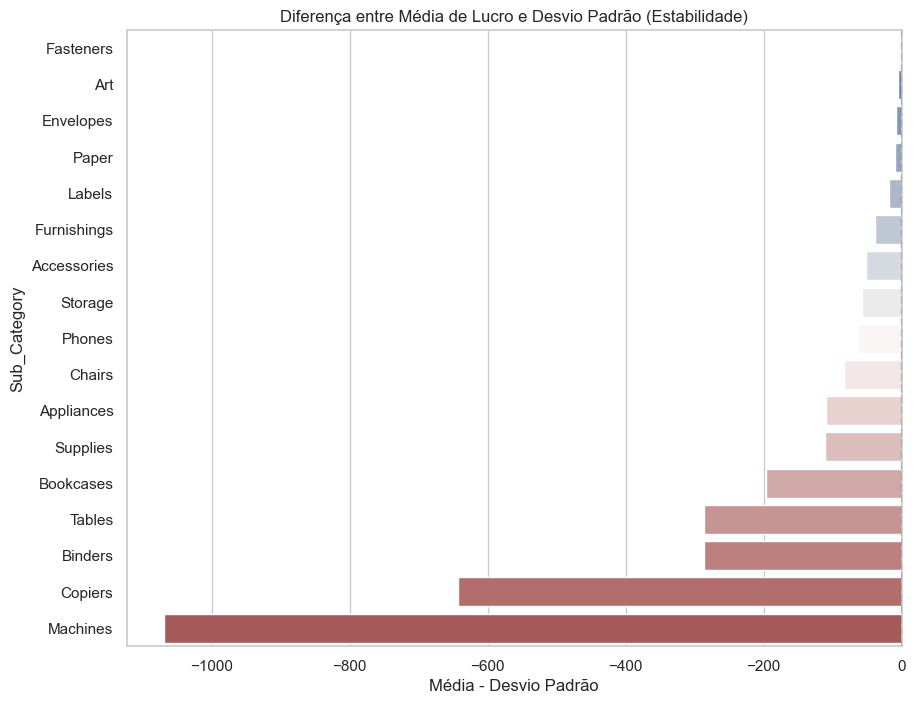

In [ ]:
# Gráfico Ranking de Estabilidade de Lucro por Subcategoria - Pipeline 1
plt.figure(figsize=(10, 8))
sns.barplot(data=df_pipe_1.sort_values('diffMean', ascending=False), 
            x='diffMean', 
            y='Sub_Category', 
            palette='vlag')
plt.title('Diferença entre Média de Lucro e Desvio Padrão (Estabilidade)')
plt.xlabel('Média - Desvio Padrão')
plt.axvline(x=0, color='black', linestyle='--') 

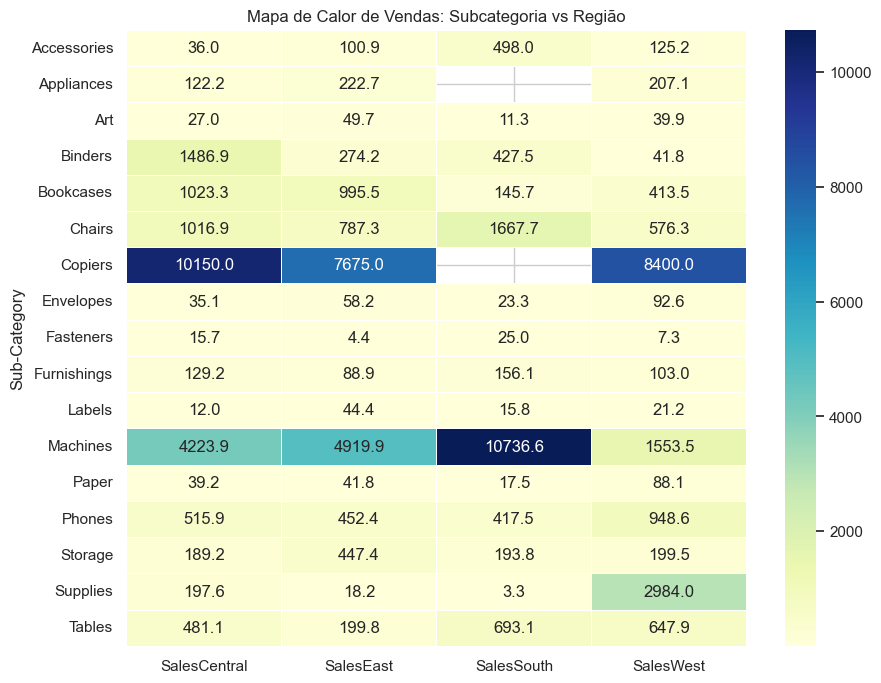

In [ ]:
# Gráfico Concentração de Vendas: Performance Regional por Produto - Pipeline 2
plt.figure(figsize=(10, 8))
sns.heatmap(df_pipe_2, 
            annot=True, 
            fmt=".1f", 
            cmap="YlGnBu", 
            linewidths=.5)
plt.title('Mapa de Calor de Vendas: Subcategoria vs Região')
plt.show()

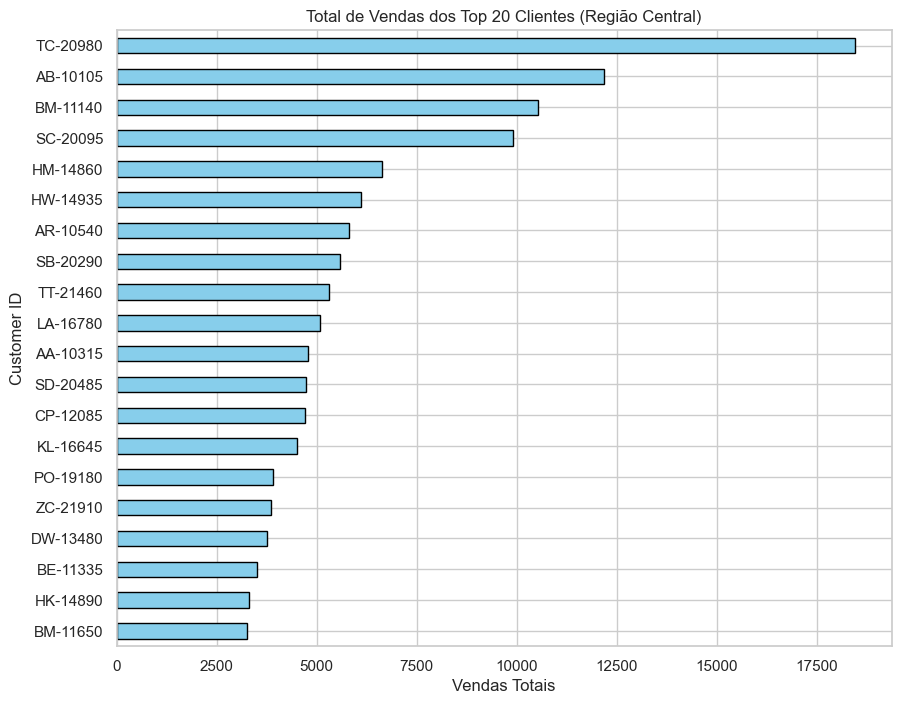

In [ ]:
# Gráfico Ranking de Vendas por Cliente - Região Central - Pipeline 3
total_por_cliente = df_pipe_3.sum(axis=1).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
total_por_cliente.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Total de Vendas dos Top 20 Clientes (Região Central)')
plt.xlabel('Vendas Totais')
plt.ylabel('Customer ID')
plt.show()

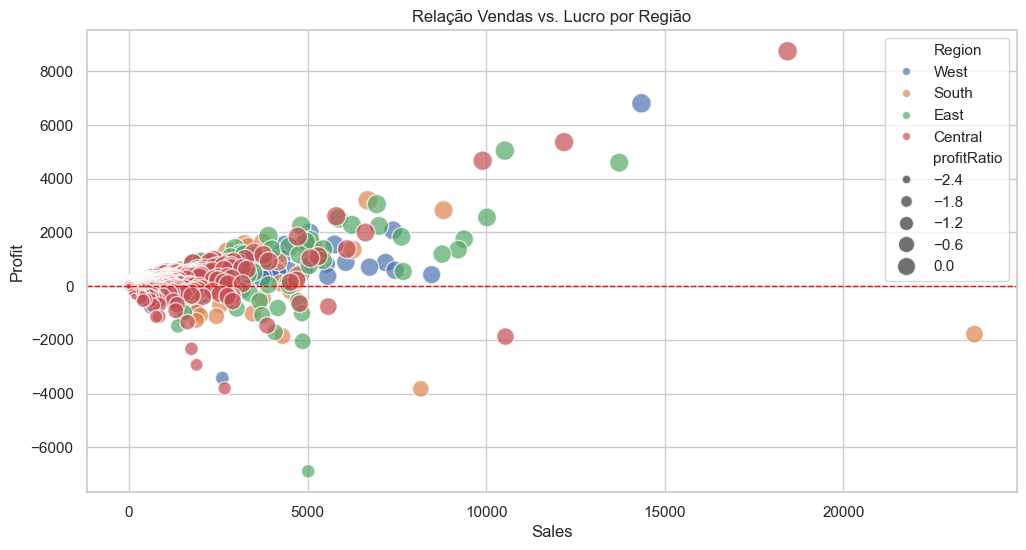

In [ ]:
# Gráfico de Dispersão para Vendas vs Lucro, colorido por Região - Pipeline 4
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_pipe_4, 
                x='Sales', 
                y='Profit', 
                hue='Region', # Colore por região para dar mais contexto
                size='profitRatio', # Tamanho da bolinha baseado na margem de lucro
                sizes=(20, 200),
                alpha=0.7)
plt.title('Relação Vendas vs. Lucro por Região')
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Linha de prejuízo zero
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_65492\2177122505.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pipe_1.sort_values('diffMean', ascending=False),


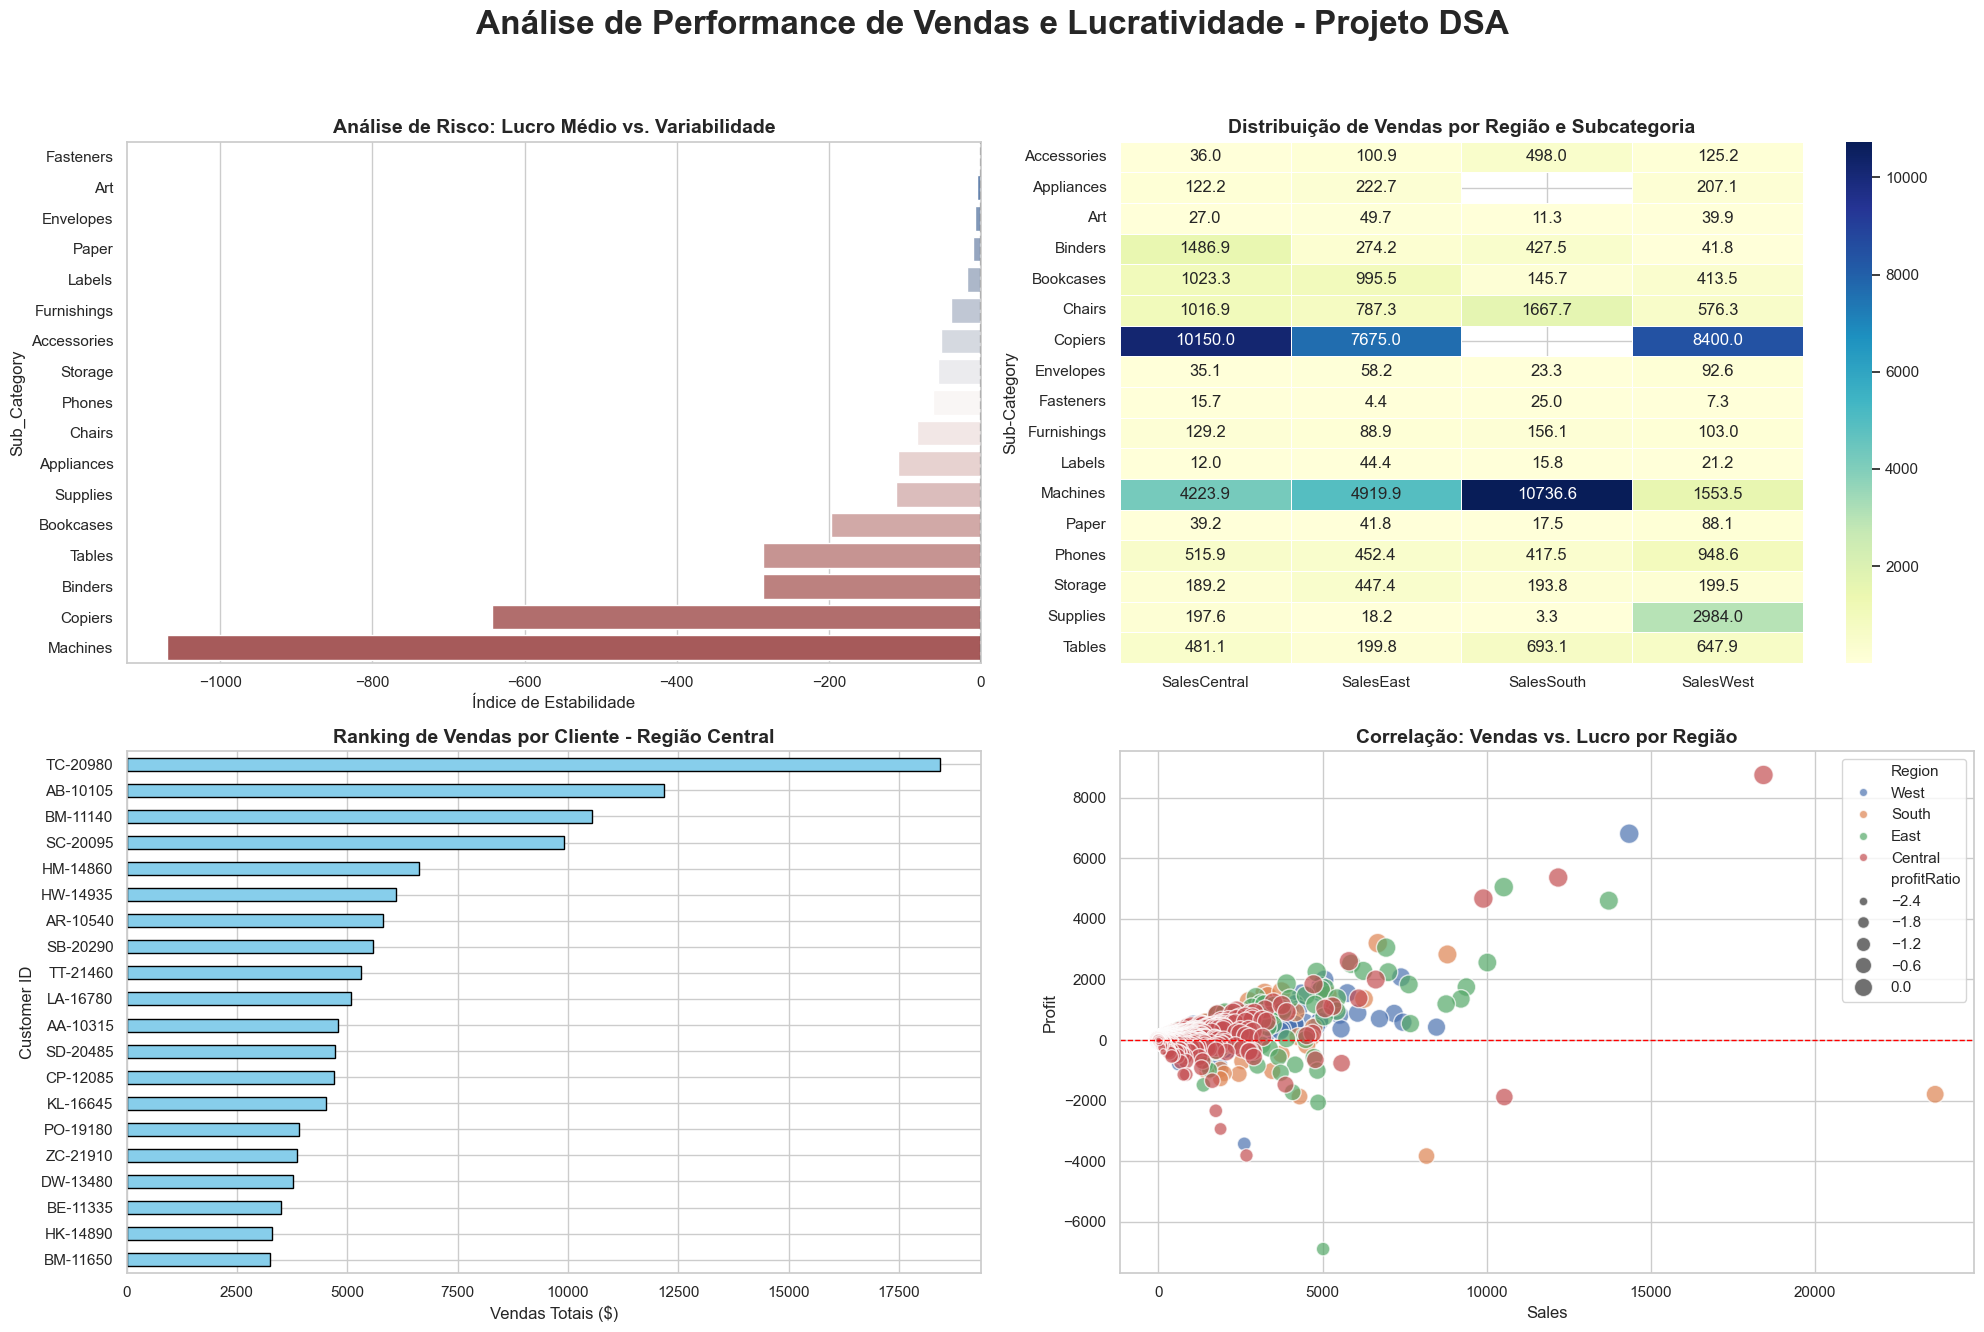

In [46]:
# Configuração do Dashboard (Área de Desenho)
# Cria uma figura grande com uma grade de 2 linhas x 2 colunas
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14))

# Título Geral do Dashboard
fig.suptitle('Análise de Performance de Vendas e Lucratividade - Projeto DSA', fontsize=24, fontweight='bold', y=0.98)

# --- GRÁFICO 1: Estabilidade (Canto Superior Esquerdo) ---
sns.barplot(data=df_pipe_1.sort_values('diffMean', ascending=False), 
            x='diffMean', 
            y='Sub_Category', 
            palette='vlag',
            ax=axes[0, 0]) # Define a posição
axes[0, 0].set_title('Análise de Risco: Lucro Médio vs. Variabilidade', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Índice de Estabilidade')
axes[0, 0].axvline(x=0, color='black', linestyle='--')

# --- GRÁFICO 2: Mapa de Calor (Canto Superior Direito) ---
sns.heatmap(df_pipe_2, 
            annot=True, 
            fmt=".1f", 
            cmap="YlGnBu", 
            linewidths=.5,
            ax=axes[0, 1]) # Define a posição
axes[0, 1].set_title('Distribuição de Vendas por Região e Subcategoria', fontsize=14, fontweight='bold')

# --- GRÁFICO 3: Top Clientes (Canto Inferior Esquerdo) ---
# Recalculando para garantir que a variável exista
total_por_cliente = df_pipe_3.sum(axis=1).sort_values(ascending=True)
total_por_cliente.plot(kind='barh', 
                       color='skyblue', 
                       edgecolor='black',
                       ax=axes[1, 0]) # Define a posição
axes[1, 0].set_title('Ranking de Vendas por Cliente - Região Central', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Vendas Totais ($)')

# --- GRÁFICO 4: Dispersão (Canto Inferior Direito) ---
sns.scatterplot(data=df_pipe_4, 
                x='Sales', 
                y='Profit', 
                hue='Region', 
                size='profitRatio', 
                sizes=(20, 200),
                alpha=0.7,
                ax=axes[1, 1]) # Define a posição
axes[1, 1].set_title('Correlação: Vendas vs. Lucro por Região', fontsize=14, fontweight='bold')
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1)

# Ajuste automático de espaçamento para nada ficar encavalado
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 

# Salva a imagem em alta qualidade na mesma pasta do seu notebook
plt.savefig('Dashboard_Projeto_Pandas_Linkedin.png', dpi=300, bbox_inches='tight')

# Mostra na tela
plt.show()